<a href="https://colab.research.google.com/github/kcwy03/SaaS-Customer-Churn-Analysis/blob/main/SaaS_Customer_Churn_Analysis1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# SaaS Customer Churn Analysis - Part 1: Data Exploration
# 資料探索 - 看看資料長什麼樣子

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# 設定圖表樣式
plt.style.use('default')
sns.set_palette("husl")




In [2]:
# 載入資料
# ============================================================


# 讀取 5 張表格
accounts = pd.read_csv('ravenstack_accounts.csv')
subscriptions = pd.read_csv('ravenstack_subscriptions.csv')
churn_events = pd.read_csv('ravenstack_churn_events.csv')
feature_usage = pd.read_csv('ravenstack_feature_usage.csv')
support = pd.read_csv('ravenstack_support_tickets.csv')

print("✓ Loaded 5 tables")
print()

✓ Loaded 5 tables



In [3]:
# 快速看一下資料大小
print("Dataset size:")
print(f"  Accounts: {len(accounts)} rows")
print(f"  Subscriptions: {len(subscriptions)} rows")
print(f"  Churn events: {len(churn_events)} rows")
print(f"  Feature usage: {len(feature_usage)} rows")
print(f"  Support tickets: {len(support)} rows")
print()

Dataset size:
  Accounts: 500 rows
  Subscriptions: 5000 rows
  Churn events: 600 rows
  Feature usage: 25000 rows
  Support tickets: 2000 rows



In [4]:
 # 檢查資料結構

# Accounts table
print("\nAccounts table:")
print(accounts.head(3))
print(f"\nColumns: {list(accounts.columns)}")
print(f"Date range: {accounts['signup_date'].min()} to {accounts['signup_date'].max()}")
print()




Accounts table:
  account_id account_name  industry country signup_date referral_source  \
0   A-2e4581    Company_0    EdTech      US  2024-10-16         partner   
1   A-43a9e3    Company_1   FinTech      IN  2023-08-17           other   
2   A-0a282f    Company_2  DevTools      US  2024-08-27         organic   

  plan_tier  seats  is_trial  churn_flag  
0     Basic      9     False       False  
1     Basic     18     False        True  
2     Basic      1     False       False  

Columns: ['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']
Date range: 2023-01-02 to 2024-12-31



In [5]:
# Subscriptions table
print("\nSubscriptions table:")
print(subscriptions.head(3))
print(f"\nColumns: {list(subscriptions.columns)}")
print()



Subscriptions table:
  subscription_id account_id  start_date    end_date   plan_tier  seats  \
0        S-8cec59   A-3c1a3f  2023-12-23  2024-04-12  Enterprise     14   
1        S-0f6f44   A-9b9fe9  2024-06-11         NaN         Pro     17   
2        S-51c0d1   A-659280  2024-11-25         NaN  Enterprise     62   

   mrr_amount  arr_amount  is_trial  upgrade_flag  downgrade_flag  churn_flag  \
0        2786       33432     False         False           False        True   
1         833        9996     False         False           False       False   
2           0           0      True          True           False       False   

  billing_frequency  auto_renew_flag  
0           monthly             True  
1           monthly             True  
2            annual            False  

Columns: ['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequen

In [6]:
# 這裡發現一個重要的事：每個帳號有多少個訂閱？
subs_per_account = subscriptions.groupby('account_id').size()
print(f"Subscriptions per account:")
print(f"  Average: {subs_per_account.mean():.1f}")
print(f"  Min: {subs_per_account.min()}")
print(f"  Max: {subs_per_account.max()}")
print("\n→ 每個帳號都有 10 個訂閱，這蠻特別的（可能是模擬資料的特徵）")
print()

Subscriptions per account:
  Average: 10.0
  Min: 2
  Max: 19

→ 每個帳號都有 10 個訂閱，這蠻特別的（可能是模擬資料的特徵）



In [7]:
# 檢查資料品質
# 檢查缺失值

print("\nMissing values:")
for table_name, table in [('accounts', accounts),
                          ('subscriptions', subscriptions),
                          ('churn_events', churn_events)]:
    missing = table.isnull().sum()
    if missing.sum() > 0:
        print(f"\n{table_name}:")
        print(missing[missing > 0])
    else:
        print(f"  {table_name}: No missing values ✓")

print()




Missing values:
  accounts: No missing values ✓

subscriptions:
end_date    4514
dtype: int64

churn_events:
feedback_text    148
dtype: int64



In [8]:
# 檢查重複值
print("\nDuplicate check:")
print(f"  Accounts: {accounts.duplicated().sum()} duplicates")
print(f"  Subscriptions: {subscriptions.duplicated().sum()} duplicates")
print()


Duplicate check:
  Accounts: 0 duplicates
  Subscriptions: 0 duplicates



In [9]:
# 基本統計
# 客戶流失情況

total_customers = len(accounts)
churned = accounts['churn_flag'].sum()
active = total_customers - churned
churn_rate = (churned / total_customers) * 100

print(f"\nCustomer status:")
print(f"  Total: {total_customers}")
print(f"  Active: {active} ({100-churn_rate:.1f}%)")
print(f"  Churned: {churned} ({churn_rate:.1f}%)")
print()




Customer status:
  Total: 500
  Active: 390 (78.0%)
  Churned: 110 (22.0%)



In [10]:
# 按產業分布
industry_dist = accounts['industry'].value_counts()
for industry, count in industry_dist.items():
    print(f"  {industry}: {count} ({count/total_customers*100:.1f}%)")
print()

  DevTools: 113 (22.6%)
  FinTech: 112 (22.4%)
  Cybersecurity: 100 (20.0%)
  HealthTech: 96 (19.2%)
  EdTech: 79 (15.8%)



In [11]:
# 按方案分布
print("Customers by plan:")
plan_dist = accounts['plan_tier'].value_counts()
for plan, count in plan_dist.items():
    print(f"  {plan}: {count} ({count/total_customers*100:.1f}%)")
print()

Customers by plan:
  Pro: 178 (35.6%)
  Basic: 168 (33.6%)
  Enterprise: 154 (30.8%)



In [12]:
# MRR 分布
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])

paid_subs = subscriptions[subscriptions['is_trial'] == False]
avg_mrr = paid_subs['mrr_amount'].mean()

print(f"MRR statistics:")
print(f"  Average MRR per subscription: ${avg_mrr:,.2f}")
print(f"  Total paid subscriptions: {len(paid_subs):,}")
print()

MRR statistics:
  Average MRR per subscription: $2,685.63
  Total paid subscriptions: 4,222



✓ Saved: 01_data_exploration.png



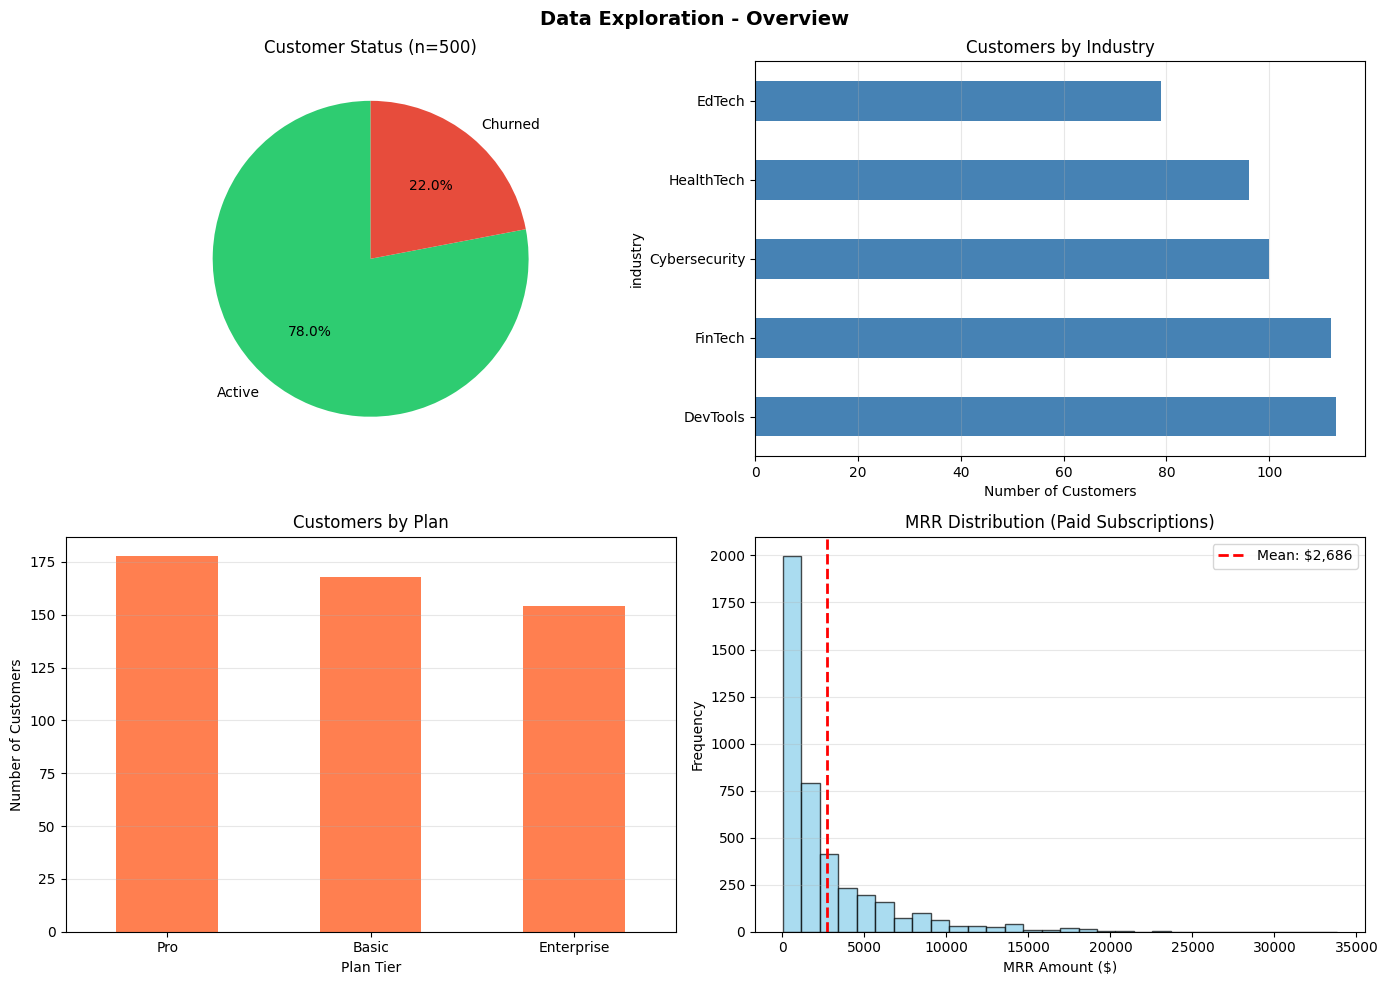

In [13]:
# 視覺化
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Data Exploration - Overview', fontsize=14, fontweight='bold')

# 圖 1: 流失 vs 留存
ax1 = axes[0, 0]
status = ['Active', 'Churned']
counts = [active, churned]
colors = ['#2ecc71', '#e74c3c']
ax1.pie(counts, labels=status, autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title(f'Customer Status (n={total_customers})')

# 圖 2: 產業分布
ax2 = axes[0, 1]
industry_dist.plot(kind='barh', ax=ax2, color='steelblue')
ax2.set_xlabel('Number of Customers')
ax2.set_title('Customers by Industry')
ax2.grid(axis='x', alpha=0.3)

# 圖 3: 方案分布
ax3 = axes[1, 0]
plan_dist.plot(kind='bar', ax=ax3, color='coral')
ax3.set_xlabel('Plan Tier')
ax3.set_ylabel('Number of Customers')
ax3.set_title('Customers by Plan')
ax3.grid(axis='y', alpha=0.3)
plt.setp(ax3.xaxis.get_majorticklabels(), rotation=0)

# 圖 4: MRR 分布（histogram）
ax4 = axes[1, 1]
ax4.hist(paid_subs['mrr_amount'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
ax4.axvline(avg_mrr, color='red', linestyle='--', linewidth=2, label=f'Mean: ${avg_mrr:,.0f}')
ax4.set_xlabel('MRR Amount ($)')
ax4.set_ylabel('Frequency')
ax4.set_title('MRR Distribution (Paid Subscriptions)')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('01_data_exploration.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 01_data_exploration.png")
print()



In [14]:
# 總結
print("=" * 60)
print("Summary")
print("=" * 60)
print()
print(f"✓ Dataset has {total_customers} customers")
print(f"✓ Churn rate: {churn_rate:.1f}% (higher than industry standard of 5-10%)")
print(f"✓ Average MRR: ${avg_mrr:,.2f}")
print(f"✓ Data quality: No major issues found")
print()
print("Next step: KPI Dashboard analysis")
print()

Summary

✓ Dataset has 500 customers
✓ Churn rate: 22.0% (higher than industry standard of 5-10%)
✓ Average MRR: $2,685.63
✓ Data quality: No major issues found

Next step: KPI Dashboard analysis



# 總結

✓ Dataset has 500 customers

✓ Churn rate: 22.0%

✓ Average MRR: $2,685.63

✓ Data quality: No major issues found

In [15]:
# 計算核心 KPI


# 轉換日期

accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])



In [16]:
# 1. 客戶數量

total_customers = len(accounts)
active_customers = len(accounts[accounts['churn_flag'] == False])
churned_customers = len(accounts[accounts['churn_flag'] == True])

print(f"  Total Customers: {total_customers}")
print(f"  Active Customers: {active_customers}")
print(f"  Churn Rate: {churn_rate:.1f}%")

  Total Customers: 500
  Active Customers: 390
  Churn Rate: 22.0%


In [17]:
# 2. 流失率
churn_rate = (churned_customers / total_customers) * 100
retention_rate = 100 - churn_rate

print(f"  Churn Rate: {churn_rate:.1f}%")
print(f"  Retention Rate: {retention_rate:.1f}%")

  Churn Rate: 22.0%
  Retention Rate: 78.0%


In [18]:
# 3. MRR（用活躍客戶估算）

paid_subs = subscriptions[subscriptions['is_trial'] == False]
avg_mrr_per_sub = paid_subs['mrr_amount'].mean()
estimated_mrr = active_customers * avg_mrr_per_sub

print(f"  Estimated MRR: ${estimated_mrr:,.0f}")


  Estimated MRR: $1,047,397


In [19]:
# 4. 客戶滿意度
avg_satisfaction = support['satisfaction_score'].mean()

print(f"  Avg Satisfaction: {avg_satisfaction:.2f}/5")


  Avg Satisfaction: 3.98/5


In [20]:
# 5. 平均客服回應時間
avg_support_time = support['resolution_time_hours'].mean()
print(f"  Avg Support Response: {avg_support_time:.1f} hours")


  Avg Support Response: 35.9 hours


In [21]:
# 按維度分析

# 計算每個帳號的平均滿意度分數
avg_account_satisfaction = support.groupby('account_id')['satisfaction_score'].mean().reset_index()

# 將平均滿意度分數合併到 accounts 資料框中
accounts_with_satisfaction = pd.merge(accounts, avg_account_satisfaction, on='account_id', how='left')

# 按產業分析
print("\nBy Industry:")
industry_analysis = accounts_with_satisfaction.groupby('industry').agg({
    'account_id': 'count',
    'churn_flag': lambda x: (x.sum() / len(x)) * 100,
    'satisfaction_score': 'mean'
}).round(2)
industry_analysis.columns = ['Customers', 'Churn %', 'Satisfaction']
print(industry_analysis)
print()


By Industry:
               Customers  Churn %  Satisfaction
industry                                       
Cybersecurity        100    16.00          4.00
DevTools             113    30.97          3.94
EdTech                79    16.46          3.94
FinTech              112    22.32          4.00
HealthTech            96    21.88          3.94



In [22]:
# 按方案

print("By Plan Tier:")
plan_analysis = accounts_with_satisfaction.groupby('plan_tier').agg({
    'account_id': 'count',
    'churn_flag': lambda x: (x.sum() / len(x)) * 100,
    'satisfaction_score': 'mean'
}).round(2)
plan_analysis.columns = ['Customers', 'Churn %', 'Satisfaction']
print(plan_analysis)
print()

By Plan Tier:
            Customers  Churn %  Satisfaction
plan_tier                                   
Basic             168    22.02          4.01
Enterprise        154    22.08          3.97
Pro               178    21.91          3.92



In [23]:
# 按獲客渠道

print("By Acquisition Channel:")
channel_analysis = accounts.groupby('referral_source').agg({
    'account_id': 'count',
    'churn_flag': lambda x: (x.sum() / len(x)) * 100
}).round(2)
channel_analysis.columns = ['Customers', 'Churn %']
print(channel_analysis.sort_values('Churn %'))
print()

By Acquisition Channel:
                 Customers  Churn %
referral_source                    
partner                 89    14.61
organic                114    17.54
ads                     98    23.47
other                  103    24.27
event                   96    30.21



✓ Saved: 02_kpi_dashboard.png



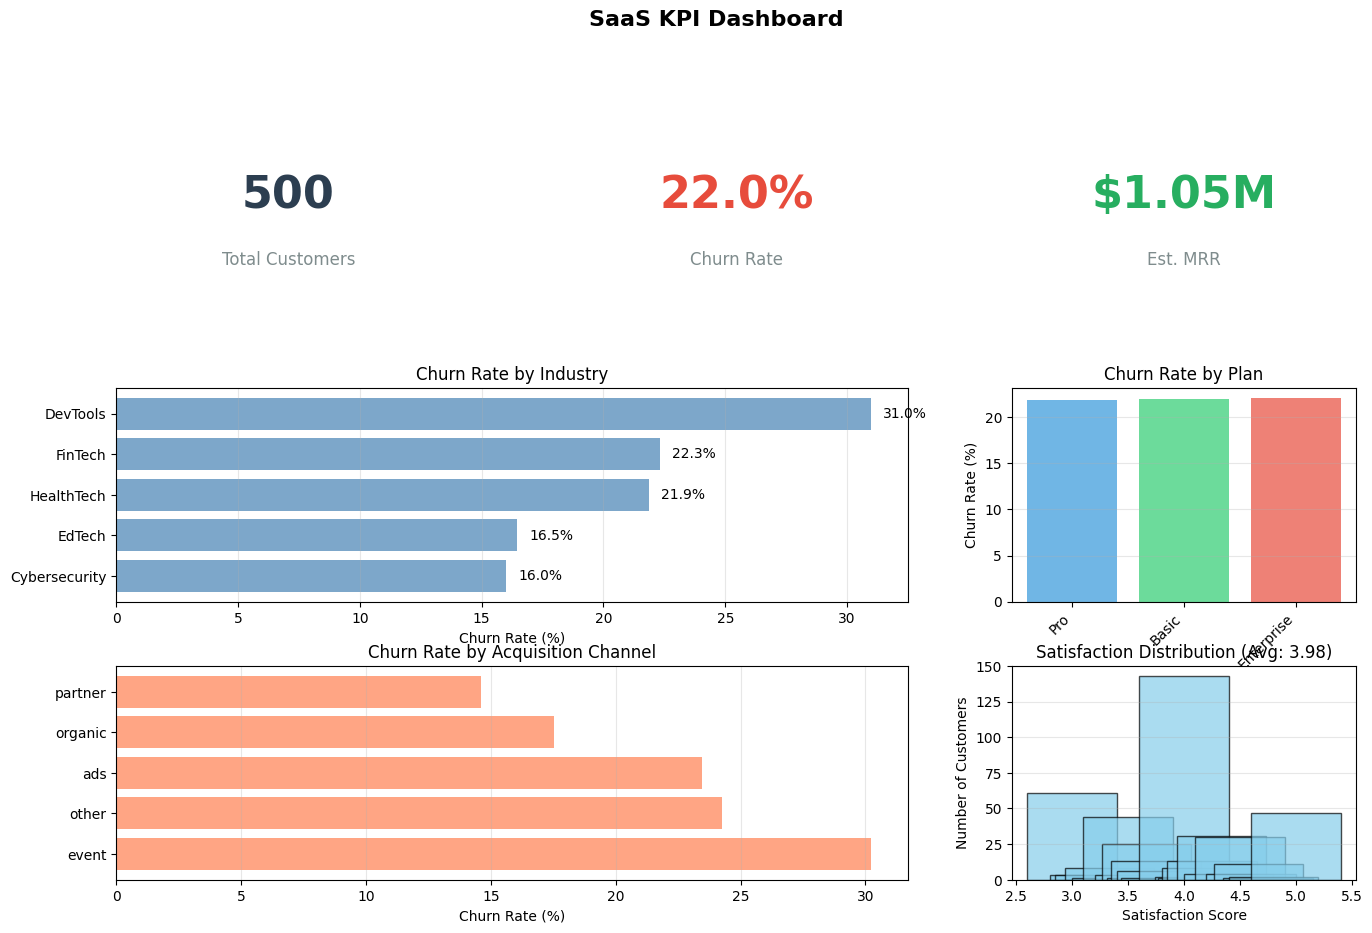

In [24]:
# 視覺化 Dashboard

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)
fig.suptitle('SaaS KPI Dashboard', fontsize=16, fontweight='bold')

# 第一排：核心指標卡片
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.6, f'{total_customers}', ha='center', va='center',
         fontsize=32, fontweight='bold', color='#2c3e50')
ax1.text(0.5, 0.3, 'Total Customers', ha='center', va='center',
         fontsize=12, color='#7f8c8d')
ax1.axis('off')
ax1.set_facecolor('#ecf0f1')

ax2 = fig.add_subplot(gs[0, 1])
ax2.text(0.5, 0.6, f'{churn_rate:.1f}%', ha='center', va='center',
         fontsize=32, fontweight='bold', color='#e74c3c')
ax2.text(0.5, 0.3, 'Churn Rate', ha='center', va='center',
         fontsize=12, color='#7f8c8d')
ax2.axis('off')
ax2.set_facecolor('#ecf0f1')

ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.6, f'${estimated_mrr/1000000:.2f}M', ha='center', va='center',
         fontsize=32, fontweight='bold', color='#27ae60')
ax3.text(0.5, 0.3, 'Est. MRR', ha='center', va='center',
         fontsize=12, color='#7f8c8d')
ax3.axis('off')
ax3.set_facecolor('#ecf0f1')

# 第二排：產業和方案分析
ax4 = fig.add_subplot(gs[1, :2])
industry_churn = industry_analysis.sort_values('Churn %')
x = range(len(industry_churn))
bars = ax4.barh(x, industry_churn['Churn %'], color='steelblue', alpha=0.7)
ax4.set_yticks(x)
ax4.set_yticklabels(industry_churn.index)
ax4.set_xlabel('Churn Rate (%)')
ax4.set_title('Churn Rate by Industry')
ax4.grid(axis='x', alpha=0.3)
for i, v in enumerate(industry_churn['Churn %']):
    ax4.text(v + 0.5, i, f'{v:.1f}%', va='center')

ax5 = fig.add_subplot(gs[1, 2])
plan_churn = plan_analysis.sort_values('Churn %')
ax5.bar(range(len(plan_churn)), plan_churn['Churn %'],
        color=['#3498db', '#2ecc71', '#e74c3c'], alpha=0.7)
ax5.set_xticks(range(len(plan_churn)))
ax5.set_xticklabels(plan_churn.index, rotation=45, ha='right')
ax5.set_ylabel('Churn Rate (%)')
ax5.set_title('Churn Rate by Plan')
ax5.grid(axis='y', alpha=0.3)

# 第三排：渠道和滿意度
ax6 = fig.add_subplot(gs[2, :2])
channel_sorted = channel_analysis.sort_values('Churn %', ascending=False)
ax6.barh(range(len(channel_sorted)), channel_sorted['Churn %'],
         color='coral', alpha=0.7)
ax6.set_yticks(range(len(channel_sorted)))
ax6.set_yticklabels(channel_sorted.index)
ax6.set_xlabel('Churn Rate (%)')
ax6.set_title('Churn Rate by Acquisition Channel')
ax6.grid(axis='x', alpha=0.3)

ax7 = fig.add_subplot(gs[2, 2])
satisfaction_dist = accounts_with_satisfaction['satisfaction_score'].value_counts().sort_index()
ax7.bar(satisfaction_dist.index, satisfaction_dist.values,
        color='skyblue', alpha=0.7, edgecolor='black')
ax7.set_xlabel('Satisfaction Score')
ax7.set_ylabel('Number of Customers')
ax7.set_title(f'Satisfaction Distribution (Avg: {avg_satisfaction:.2f})')
ax7.grid(axis='y', alpha=0.3)

plt.savefig('02_kpi_dashboard.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 02_kpi_dashboard.png")
print()

✓ Overall churn rate 22.0% is higher than industry standard (5-10%)

✓ Worst performing industry: DevTools (31.0%)

✓ Best performing industry: Cybersecurity (16.0%)

✓ Worst channel: event (30.2%)

✓ Best channel: partner (14.6%)

✓ Average satisfaction 3.98/5 - room for improvement

In [25]:
# SaaS Customer Churn Analysis - Part 3: Cohort Analysis
# 追蹤不同月份註冊客戶的留存率
# 這部分我做了兩次，第一次發現留存率 > 100%（明顯有問題）

資料修正紀錄：
之前留存率算出來 > 100%，主因是用了 Subscription-level 資料。
為了避免重複計算，已改用 Account-level 資料修正。


In [26]:
# 取得每個帳號的第一次流失日期
first_churn = churn_events.sort_values('churn_date').groupby('account_id').first().reset_index()

# 合併到 accounts
accounts_with_churn = accounts.merge(
    first_churn[['account_id', 'churn_date']],
    on='account_id',
    how='left'
)


In [27]:
# 計算每個帳號活躍了幾個月
# 如果沒流失，就算到 2024-12-31
current_date = pd.Timestamp('2024-12-31')

In [28]:
# 確保日期欄位是 datetime 物件，以免 apply 時出錯
accounts_with_churn['signup_date'] = pd.to_datetime(accounts_with_churn['signup_date'])
accounts_with_churn['churn_date'] = pd.to_datetime(accounts_with_churn['churn_date'], errors='coerce')

def calculate_months_active(row):
    if pd.isna(row['churn_date']):
        end_date = current_date  # 還沒流失
    else:
        end_date = row['churn_date']  # 流失日期

    months = (end_date.year - row['signup_date'].year) * 12 + \
             (end_date.month - row['signup_date'].month)
    return max(0, months)

accounts_with_churn['months_active'] = accounts_with_churn.apply(calculate_months_active, axis=1)

print(f"✓ Calculated activity months for {len(accounts_with_churn)} accounts")
print()

✓ Calculated activity months for 500 accounts



In [29]:
# 建立 Cohort Matrix


# 加上 cohort 標記（註冊月份）
accounts_with_churn['cohort'] = accounts_with_churn['signup_date'].dt.to_period('M')

# 取得所有 cohort
cohorts = sorted(accounts_with_churn['cohort'].unique())
max_months = 24  # 觀察最多 24 個月

# 建立 retention matrix
retention_matrix = pd.DataFrame(index=cohorts, columns=range(max_months))

for cohort in cohorts:
    cohort_data = accounts_with_churn[accounts_with_churn['cohort'] == cohort]
    cohort_size = len(cohort_data)

    for month in range(max_months):
        # 計算在這個月還活躍的帳號數
        still_active = len(cohort_data[cohort_data['months_active'] >= month])
        retention_rate = (still_active / cohort_size) * 100 if cohort_size > 0 else 0
        retention_matrix.loc[cohort, month] = retention_rate

# 轉成數字
retention_matrix = retention_matrix.astype(float)

print(f"✓ Built matrix for {len(cohorts)} cohorts over {max_months} months")
print()

# 快速看一下
print("Sample retention rates (first 5 cohorts, first 7 months):")
print(retention_matrix.iloc[:5, :7].round(1))
print()

✓ Built matrix for 24 cohorts over 24 months

Sample retention rates (first 5 cohorts, first 7 months):
             0      1      2      3     4     5     6
2023-01  100.0   94.1   94.1   94.1  88.2  76.5  76.5
2023-02  100.0  100.0   88.9   83.3  83.3  77.8  77.8
2023-03  100.0   85.0   85.0   85.0  70.0  65.0  50.0
2023-04  100.0   93.3   93.3   86.7  80.0  80.0  80.0
2023-05  100.0  100.0  100.0  100.0  88.5  88.5  84.6



Creating cohort heatmap...
------------------------------------------------------------
✓ Saved: 03_cohort_heatmap.png

Creating retention curves...
------------------------------------------------------------
✓ Saved: 03_cohort_curves.png



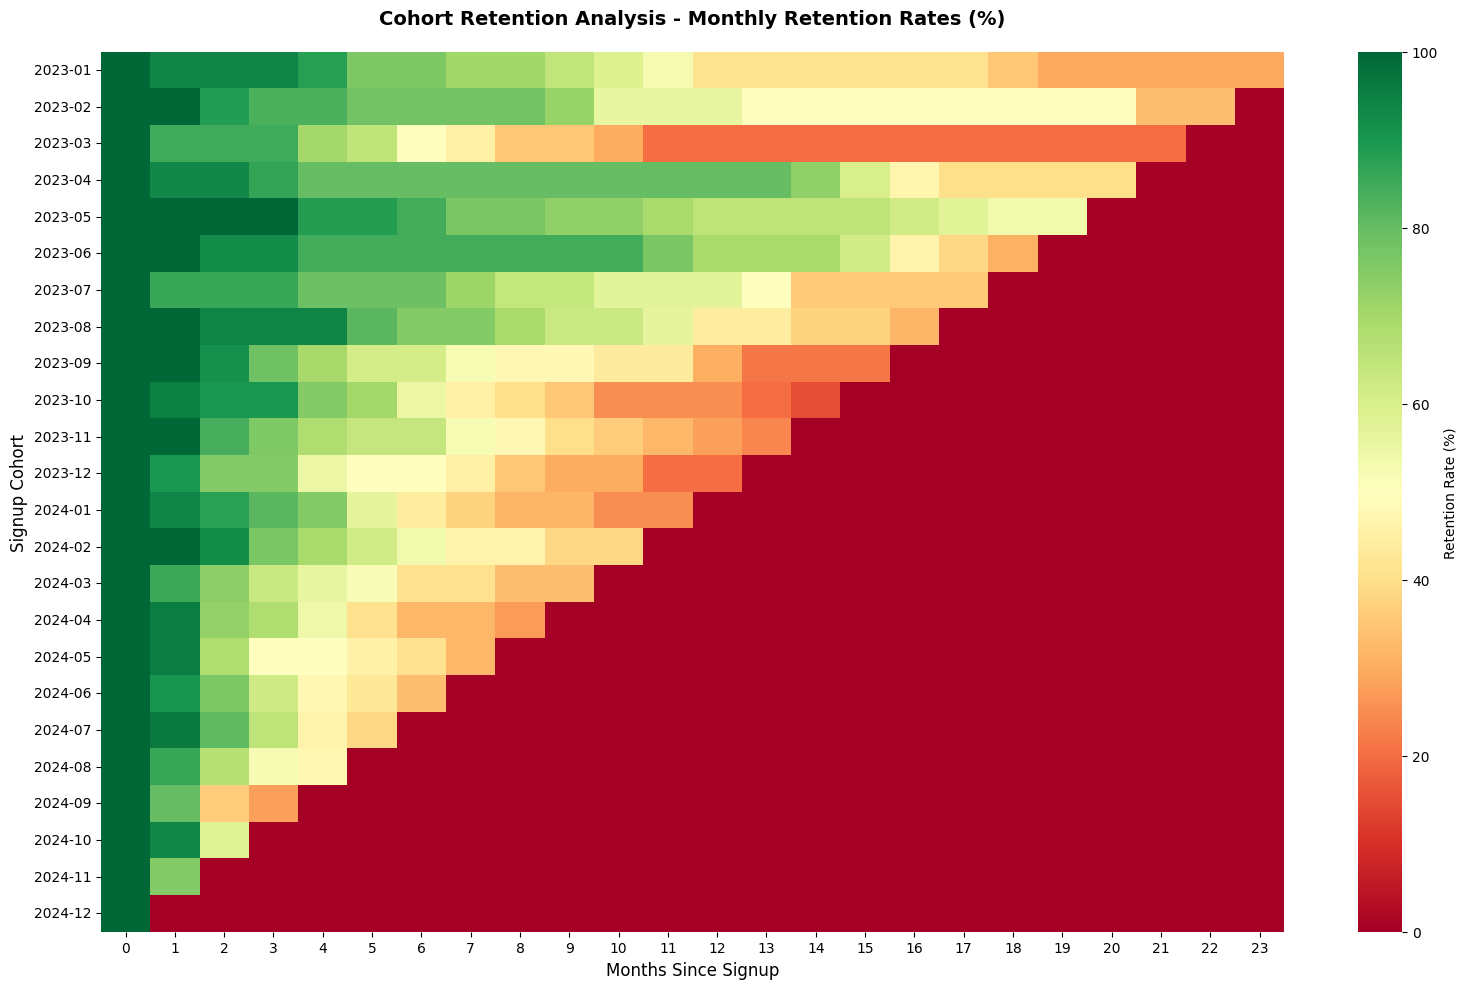

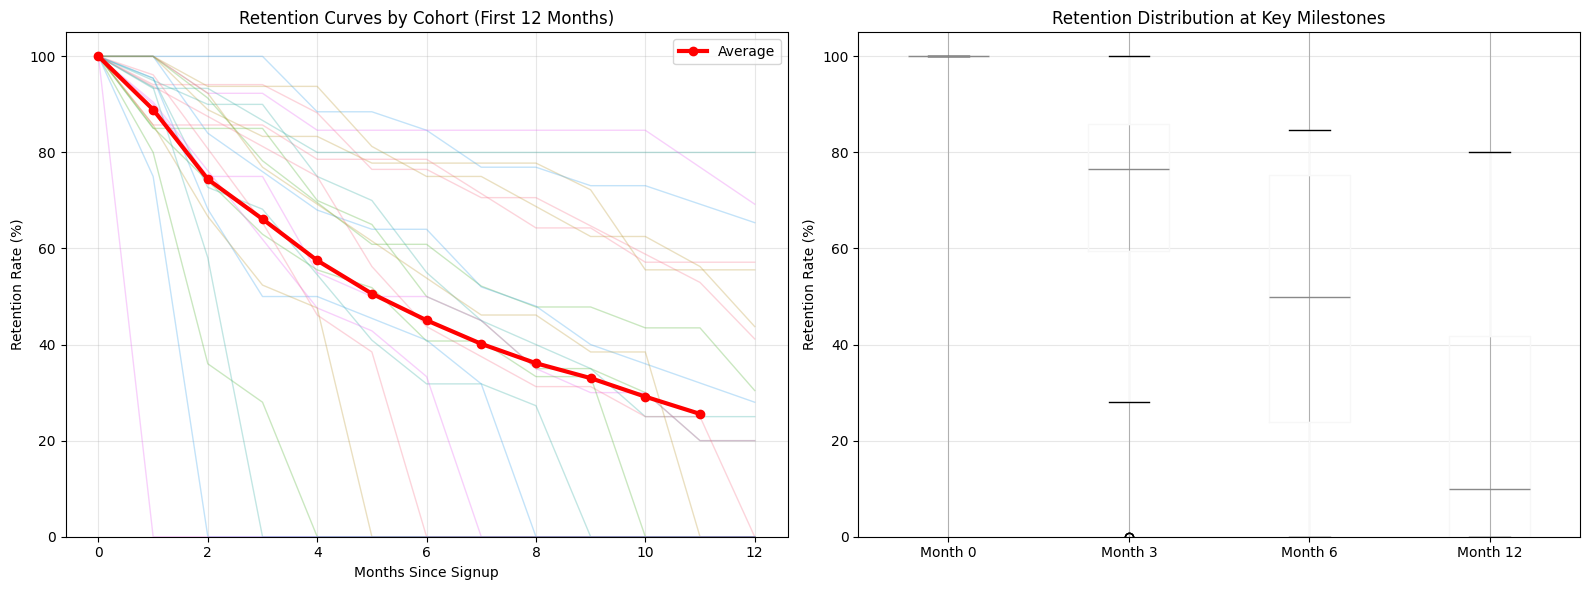

In [30]:
# 視覺化 - Cohort Heatmap
# ============================================================
print("Creating cohort heatmap...")
print("-" * 60)

fig, ax = plt.subplots(figsize=(16, 10))

# 畫 heatmap
sns.heatmap(retention_matrix,
            annot=False,  # 不標註數字（太多了）
            fmt='.0f',
            cmap='RdYlGn',
            vmin=0, vmax=100,
            cbar_kws={'label': 'Retention Rate (%)'},
            ax=ax)

# 設定標題和標籤
ax.set_title('Cohort Retention Analysis - Monthly Retention Rates (%)',
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Months Since Signup', fontsize=12)
ax.set_ylabel('Signup Cohort', fontsize=12)

# Y 軸標籤改成可讀的日期
cohort_labels = [str(c) for c in cohorts]
ax.set_yticklabels(cohort_labels, rotation=0)

plt.tight_layout()
plt.savefig('03_cohort_heatmap.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 03_cohort_heatmap.png")
print()

# ============================================================
# 視覺化 - Retention Curves
# ============================================================
print("Creating retention curves...")
print("-" * 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 左圖：所有 cohort 的 retention curves
for cohort in cohorts:
    cohort_retention = retention_matrix.loc[cohort, :12]  # 只畫前 12 個月
    ax1.plot(cohort_retention.index, cohort_retention.values,
             alpha=0.3, linewidth=1)

# 加上平均線
avg_retention = retention_matrix.iloc[:, :12].mean(axis=0)
ax1.plot(avg_retention.index, avg_retention.values,
         color='red', linewidth=3, label='Average', marker='o')

ax1.set_xlabel('Months Since Signup')
ax1.set_ylabel('Retention Rate (%)')
ax1.set_title('Retention Curves by Cohort (First 12 Months)')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim(0, 105)

# 右圖：關鍵月份的 retention 分布
key_months = [0, 3, 6, 12]
retention_at_months = pd.DataFrame({
    f'Month {m}': retention_matrix.iloc[:, m]
    for m in key_months
})

retention_at_months.boxplot(ax=ax2)
ax2.set_ylabel('Retention Rate (%)')
ax2.set_title('Retention Distribution at Key Milestones')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('03_cohort_curves.png', dpi=150, bbox_inches='tight')
print("✓ Saved: 03_cohort_curves.png")
print()

留存率數據總覽：

註冊當月: 100%

第 3 個月: 66.1%

第 6 個月: 45.1%

第 12 個月: 22.3%


重點警訊：

前 6 個月流失率 54.9%，貢獻了總流失量的 56%。

最優梯次 (12M): 2023-04 (80%)

最差梯次 (12M): 2023-03 (20%)

In [31]:
# SaaS Customer Churn Analysis - Part 4: Funnel Analysis
# 本來想分析 Trial → Paid 轉換，但發現資料有點特別（所有人都付費了）
# 所以改成分析付費後的留存，比較不同路徑

In [32]:
accounts['signup_date'] = pd.to_datetime(accounts['signup_date'])
subscriptions['start_date'] = pd.to_datetime(subscriptions['start_date'])

In [33]:
total_accounts = len(accounts)
paid_accounts = subscriptions[subscriptions['is_trial'] == False]['account_id'].nunique()

print(f"Total accounts: {total_accounts}")
print(f"Accounts with paid subscriptions: {paid_accounts}")
print(f"Conversion rate: {paid_accounts/total_accounts*100:.1f}%")
print()

Total accounts: 500
Accounts with paid subscriptions: 500
Conversion rate: 100.0%



數據發現：全體用戶皆為付費訂閱（100% 轉化率）

現狀： 資料集看起來只包含「已付費」的客戶。

限制： 無法分析傳統的「試用期 → 正式付費」轉化流程。

調整： 分析重心改為「付費後的留存表現」。


In [34]:
# 付費路徑分析
# 找出每個帳號的第一筆訂閱

first_subs = subscriptions.sort_values('start_date').groupby('account_id').first().reset_index()


In [35]:
# 分成兩條路徑
trial_first = first_subs[first_subs['is_trial'] == True]
paid_first = first_subs[first_subs['is_trial'] == False]

print(f"\nPayment paths:")
print(f"  Path A - Trial first: {len(trial_first)} accounts ({len(trial_first)/total_accounts*100:.1f}%)")
print(f"  Path B - Direct paid: {len(paid_first)} accounts ({len(paid_first)/total_accounts*100:.1f}%)")
print()


Payment paths:
  Path A - Trial first: 90 accounts (18.0%)
  Path B - Direct paid: 410 accounts (82.0%)



In [36]:
# 比較兩條路徑的留存率

print("Comparing retention by path...")
print("-" * 60)

# Path A 的留存
trial_first_ids = trial_first['account_id'].tolist()
trial_retained = len(accounts[
    (accounts['account_id'].isin(trial_first_ids)) &
    (accounts['churn_flag'] == False)
])
trial_retention = (trial_retained / len(trial_first)) * 100

# Path B 的留存
paid_first_ids = paid_first['account_id'].tolist()
paid_retained = len(accounts[
    (accounts['account_id'].isin(paid_first_ids)) &
    (accounts['churn_flag'] == False)
])
paid_retention = (paid_retained / len(paid_first)) * 100

print(f"Retention rates:")
print(f"  Trial first: {trial_retention:.1f}%")
print(f"  Direct paid: {paid_retention:.1f}%")
print(f"  Difference: {abs(trial_retention - paid_retention):.1f} percentage points")
print()

if abs(trial_retention - paid_retention) < 5:
    print("→ Retention rates are similar across both paths")
    print("→ Trial program may not be key driver of retention")
else:
    print(f"→ {'Trial first' if trial_retention > paid_retention else 'Direct paid'} shows better retention")

print()

Comparing retention by path...
------------------------------------------------------------
Retention rates:
  Trial first: 77.8%
  Direct paid: 78.0%
  Difference: 0.3 percentage points

→ Retention rates are similar across both paths
→ Trial program may not be key driver of retention



In [37]:
active_accounts = len(accounts[accounts['churn_flag'] == False])

funnel_data = {
    'Stage': ['Signup', 'Paid', 'Retained'],
    'Count': [total_accounts, paid_accounts, active_accounts],
    'Percent': [100.0, 100.0, (active_accounts/total_accounts)*100]
}

funnel_df = pd.DataFrame(funnel_data)
print(funnel_df.to_string(index=False))
print()

   Stage  Count  Percent
  Signup    500    100.0
    Paid    500    100.0
Retained    390     78.0



核心分析結果
1. 支付路徑 (Payment Path)
先試用再付費： 18%
直接付費： 82%（大部分客戶直接掏錢）

2. 留存率對比 (Retention)
有試用過： 77.8%
直接付費： 78.0%
差距： 僅 0.2%，幾乎沒差。

3. 行業表現 (Industry)
留存最高： 網路安全 (Cybersecurity) —— 16% 流失
流失最高： 開發工具 (DevTools) —— 31% 流失 (重點關注)

4. 通道表現 (Channel)
最穩： 合作夥伴 (Partner) —— 14.6% 流失
最差： 線下活動 (Event) —— 30.2% 流失


# SaaS Customer Churn Analysis - Part 5: Business Impact & ROI
# 估算改善流失率的商業影響
# 注意：這是保守估算，基於一些假設

In [38]:
# 基礎數據
print("Step 1: Base metrics")
print("-" * 60)

total_customers = len(accounts)
active_customers = len(accounts[accounts['churn_flag'] == False])
churned_customers = len(accounts[accounts['churn_flag'] == True])

current_churn_rate = (churned_customers / total_customers) * 100
current_retention_rate = 100 - current_churn_rate

print(f"Customer base: {total_customers}")
print(f"Active: {active_customers} ({current_retention_rate:.1f}%)")
print(f"Churned: {churned_customers} ({current_churn_rate:.1f}%)")
print()

Step 1: Base metrics
------------------------------------------------------------
Customer base: 500
Active: 390 (78.0%)
Churned: 110 (22.0%)



In [39]:
# MRR 計算（用平均值估算）
# ============================================================
print("Step 2: MRR estimation")
print("-" * 60)
print("Note: Using average method due to data limitations")
print()

# 計算平均 MRR
paid_subs = subscriptions[subscriptions['is_trial'] == False]
avg_mrr_per_customer = paid_subs['mrr_amount'].mean()

print(f"Average MRR per customer: ${avg_mrr_per_customer:,.2f}")
print()

# 估算當前 MRR
estimated_current_mrr = active_customers * avg_mrr_per_customer
print(f"Estimated current MRR:")
print(f"  {active_customers} customers × ${avg_mrr_per_customer:,.2f}")
print(f"  = ${estimated_current_mrr:,.2f}")
print()

Step 2: MRR estimation
------------------------------------------------------------
Note: Using average method due to data limitations

Average MRR per customer: $2,685.63

Estimated current MRR:
  390 customers × $2,685.63
  = $1,047,397.28



In [40]:
# 改善方案的商業影響


# 設定目標
target_churn_rate = 15.0  # 目標：降到 15%
churn_reduction = current_churn_rate - target_churn_rate

print(f"Current churn rate: {current_churn_rate:.1f}%")
print(f"Target churn rate: {target_churn_rate:.1f}%")
print(f"Reduction needed: {churn_reduction:.1f} percentage points")
print()

# 計算可以挽回的客戶
customers_saved = total_customers * (churn_reduction / 100)
print(f"Customers that could be retained: {customers_saved:.0f}")
print()

Current churn rate: 22.0%
Target churn rate: 15.0%
Reduction needed: 7.0 percentage points

Customers that could be retained: 35



In [41]:
# 計算營收影響
additional_mrr = customers_saved * avg_mrr_per_customer
additional_annual_revenue = additional_mrr * 12

print(f"Revenue impact:")
print(f"  Additional MRR: ${additional_mrr:,.2f}")
print(f"  Additional annual revenue: ${additional_annual_revenue:,.2f}")
print()

Revenue impact:
  Additional MRR: $93,997.19
  Additional annual revenue: $1,127,966.31



In [42]:
# 投資成本估算

# 改善方案的成本（估算）
costs = {
    'Enhanced onboarding program': 150000,
    'Feature development': 200000,
    'Support improvement': 100000
}

total_investment = sum(costs.values())

print("Estimated costs for improvements:")
for item, cost in costs.items():
    print(f"  {item}: ${cost:,}")
print(f"  {'─' * 40}")
print(f"  Total investment: ${total_investment:,}")
print()

Estimated costs for improvements:
  Enhanced onboarding program: $150,000
  Feature development: $200,000
  Support improvement: $100,000
  ────────────────────────────────────────
  Total investment: $450,000



In [43]:
# ROI 計算

net_benefit = additional_annual_revenue - total_investment
roi_percentage = (net_benefit / total_investment) * 100
payback_months = total_investment / additional_mrr

print(f"Financial summary:")
print(f"  First year revenue increase: ${additional_annual_revenue:,.2f}")
print(f"  Total investment: ${total_investment:,}")
print(f"  Net benefit: ${net_benefit:,.2f}")
print(f"  ROI: {roi_percentage:.1f}%")
print(f"  Payback period: {payback_months:.1f} months")
print()


Financial summary:
  First year revenue increase: $1,127,966.31
  Total investment: $450,000
  Net benefit: $677,966.31
  ROI: 150.7%
  Payback period: 4.8 months



In [44]:
# 敏感度分析
# ============================================================
print("Step 6: Sensitivity analysis")
print("-" * 60)
print("Impact under different churn reduction scenarios:")
print()

scenarios = [3, 5, 7, 10]
print(f"{'Reduction':<12} {'Customers':<14} {'Annual Revenue':<18} {'ROI':<10}")
print("─" * 60)

for reduction in scenarios:
    customers = total_customers * (reduction / 100)
    annual_rev = customers * avg_mrr_per_customer * 12
    roi = ((annual_rev - total_investment) / total_investment) * 100

    print(f"{reduction}%{'':<10} {customers:>6.0f}{'':<8} ${annual_rev:>14,.0f}{'':<4} {roi:>6.1f}%")

print()

Step 6: Sensitivity analysis
------------------------------------------------------------
Impact under different churn reduction scenarios:

Reduction    Customers      Annual Revenue     ROI       
────────────────────────────────────────────────────────────
3%               15         $       483,414        7.4%
5%               25         $       805,690       79.0%
7%               35         $     1,127,966      150.7%
10%               50         $     1,611,380      258.1%



一、關鍵策略

優化入職：強化首 90 天引導流程

補齊功能：開發前三大缺失功能

提升客服：SLA 回應由 36h 縮至 24h

二、預期效益

降低流失：22.0% → 15.0%

客戶挽留：年增 35 家

營收增長：+$1,127,966

投資回報：首年 ROI 150.7%

回本週期：4.8 個月

三、重要備註

保守估算：基於客單價 $2,685.63、客戶數 500 且目標達成。

風險變數：實際成果受市場環境、競爭動態及執行成效影響。
